In [20]:
import pandas as pd
import json

# Load all CSVs
roads = pd.read_csv("../data/road_network.csv")
traffic = pd.read_csv("../data/traffic_sensor_data.csv")
weather = pd.read_csv("../data/weather_conditions.csv")
events = pd.read_csv("../data/traffic_events.csv")

# Load JSON
with open("../data/sensor_locations.json") as f:
    sensors = json.load(f)

# Convert sensors JSON into DataFrame
sensors_df = pd.DataFrame(sensors["sensors"])



In [21]:
# Merge sensors with roads
roads_sensors = sensors_df.merge(roads, left_on="road_segment_id", right_on="road_id", how="left")
print(roads_sensors.head())

# Merge traffic with sensors
traffic_full = traffic.merge(sensors_df, on="sensor_id", how="left")
print(traffic_full.head())

# Merge traffic with weather
traffic_weather = traffic_full.merge(weather, on="timestamp", how="left")

# Check events columns before merging
print(events.columns)

# Example merge (adjust keys if needed)
traffic_all = traffic_weather.merge(
    events,
    left_on="timestamp",
    right_on="timestamp_start",
    how="left"
)

print(traffic_all.head())
print(traffic_all.info())

  sensor_id                    location_name  \
0   SEN-001       Jl. Sudirman - Bundaran HI   
1   SEN-002              Jl. Thamrin - Monas   
2   SEN-003     Jl. Gatot Subroto - Kuningan   
3   SEN-004      Jl. Rasuna Said - Setiabudi   
4   SEN-005  Jl. HR Rasuna Said - Casablanca   

                                        coordinates sensor_type  \
0  {'latitude': -6.337762, 'longitude': 106.853379}      Camera   
1  {'latitude': -6.140999, 'longitude': 106.792419}       Lidar   
2  {'latitude': -6.227011, 'longitude': 106.738791}    Infrared   
3  {'latitude': -6.186329, 'longitude': 106.744133}      Camera   
4  {'latitude': -6.245345, 'longitude': 106.974337}       Lidar   

  installation_date  status coverage_direction  detection_range_m  \
0        2021-03-17  Active               East                 15   
1        2021-03-19  Active               West                 50   
2        2023-02-16  Active         South-West                 20   
3        2021-09-01  Active     

In [22]:
print(traffic_all.head())
print(traffic_all.info())


             timestamp sensor_id                    location direction  \
0  2024-01-01 00:00:00   SEN-001  Jl. Sudirman - Bundaran HI     North   
1  2024-01-01 00:00:00   SEN-001  Jl. Sudirman - Bundaran HI     North   
2  2024-01-01 00:00:00   SEN-001  Jl. Sudirman - Bundaran HI     North   
3  2024-01-01 00:00:00   SEN-001  Jl. Sudirman - Bundaran HI     North   
4  2024-01-01 00:00:00   SEN-001  Jl. Sudirman - Bundaran HI     North   

   vehicle_count  average_speed_kmh  occupancy_rate congestion_level  \
0             14               67.8           0.073              Low   
1             14               67.8           0.073              Low   
2             14               67.8           0.073              Low   
3             14               67.8           0.073              Low   
4             14               67.8           0.073              Low   

   car_count  motorcycle_count  ...  location_description  severity  \
0          6                 5  ...                

In [23]:
import pandas as pd

# Road network data
roads = pd.read_csv("../data/road_network.csv")
print("Roads:", roads.shape)
print(roads.head())

# Traffic sensor data
traffic = pd.read_csv("../data/traffic_sensor_data.csv")
print("Traffic:", traffic.shape)
print(traffic.head())

# Weather conditions
weather = pd.read_csv("../data/weather_conditions.csv")
print("Weather:", weather.shape)
print(weather.head())

# Traffic events
events = pd.read_csv("../data/traffic_events.csv")
print("Events:", events.shape)
print(events.head())


Roads: (200, 18)
   road_id      road_name       road_type  length_km  lanes  speed_limit_kmh  \
0  RD-0001  Jl. Segment 1  Jalan Kolektor        4.3      4               60   
1  RD-0002  Jl. Segment 2    Jalan Arteri        4.3      4               80   
2  RD-0003  Jl. Segment 3     Jalan Lokal        1.8      2               40   
3  RD-0004  Jl. Segment 4  Jalan Kolektor        1.8      4               60   
4  RD-0005  Jl. Segment 5       Jalan Tol       22.7      4               80   

   capacity_vehicles_per_hour  has_bus_lane  has_bike_lane surface_condition  \
0                        5384             0              0             Cukup   
1                        6132             0              0              Baik   
2                         978             0              0             Cukup   
3                        4160             0              1       Rusak Berat   
4                        6600             1              0              Baik   

  last_maintenance_da

In [25]:
import json

with open("../data/sensor_locations.json") as f:
    sensors = json.load(f)

# If it's a dictionary, show keys
print(sensors.keys())

# If you want to peek inside
for key, value in list(sensors.items())[:2]:
    print(key, value)


dict_keys(['dataset_info', 'sensors'])
dataset_info {'name': 'Smart City Traffic Sensor Network - Jakarta', 'description': 'Metadata dan konfigurasi sensor lalu lintas di wilayah DKI Jakarta', 'total_sensors': 50, 'last_updated': '2024-03-31T23:55:00+07:00', 'coordinate_system': 'WGS84', 'coverage_area': 'DKI Jakarta dan sekitarnya'}
sensors [{'sensor_id': 'SEN-001', 'location_name': 'Jl. Sudirman - Bundaran HI', 'coordinates': {'latitude': -6.337762, 'longitude': 106.853379}, 'sensor_type': 'Camera', 'installation_date': '2021-03-17', 'status': 'Active', 'coverage_direction': 'East', 'detection_range_m': 15, 'sampling_rate_seconds': 300, 'road_segment_id': 'RD-0126', 'district': 'Cakung', 'calibration_date': '2023-12-13', 'firmware_version': 'v2.2.3', 'communication_protocol': 'LoRaWAN', 'power_source': 'Hybrid', 'last_data_transmission': '2024-03-30 10:56:00', 'metadata': {'manufacturer': 'Siemens', 'model': 'X-Stream', 'height_m': 5.8, 'lane_coverage': 3, 'has_anpr': True, 'has_spee

In [26]:
traffic.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218400 entries, 0 to 218399
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          218400 non-null  object 
 1   sensor_id          218400 non-null  object 
 2   location           218400 non-null  object 
 3   direction          218400 non-null  object 
 4   vehicle_count      218400 non-null  int64  
 5   average_speed_kmh  218400 non-null  float64
 6   occupancy_rate     218400 non-null  float64
 7   congestion_level   218400 non-null  object 
 8   car_count          218400 non-null  int64  
 9   motorcycle_count   218400 non-null  int64  
 10  truck_count        218400 non-null  int64  
 11  bus_count          218400 non-null  int64  
 12  day_of_week        218400 non-null  int64  
 13  is_holiday         218400 non-null  int64  
 14  hour               218400 non-null  int64  
dtypes: float64(2), int64(8), object(5)
memory usage: 25

In [27]:
weather = pd.read_csv("../data/weather_conditions.csv")
print(weather.head())
events = pd.read_csv("../data/traffic_events.csv")
print(events.head())


             timestamp station_id  temperature_c  humidity_pct  \
0  2024-01-01 00:00:00      WS-01           23.8          59.8   
1  2024-01-01 00:00:00      WS-02           23.9          59.0   
2  2024-01-01 00:00:00      WS-03           23.4          63.8   
3  2024-01-01 00:00:00      WS-04           23.4          62.3   
4  2024-01-01 00:00:00      WS-05           23.2          64.1   

   precipitation_mm  wind_speed_kmh  visibility_km  weather_type  \
0               3.5            11.4            5.5  Hujan Ringan   
1               4.5            13.6            5.3  Hujan Ringan   
2               5.4            13.5            5.3  Hujan Ringan   
3               6.6            14.9            5.1  Hujan Ringan   
4               5.6            12.7            5.3  Hujan Ringan   

   air_quality_index  uv_index  pressure_hpa  
0                 49       0.0        1013.2  
1                 61       0.0        1011.7  
2                 59       0.0        1012.8  
3     

In [28]:
traffic.describe()


,vehicle_count,average_speed_kmh,occupancy_rate,car_count,motorcycle_count,truck_count,bus_count,day_of_week,is_holiday,hour
count,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000,218400.000000
mean,39.238462,57.978488,0.241431,16.176296,14.213397,2.053608,6.795783,3.000000,0.329670,11.500000
std,28.509697,22.526444,0.142765,12.315940,10.885097,2.100901,4.994987,2.000005,0.470094,6.922202
min,0.000000,7.700000,0.025000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,36.400000,0.129000,7.000000,6.000000,1.000000,3.000000,1.000000,0.000000,5.750000
50%,32.000000,64.000000,0.222000,13.000000,11.000000,1.000000,5.000000,3.000000,0.000000,11.500000
75%,55.000000,80.000000,0.317000,23.000000,20.000000,3.000000,9.000000,5.000000,1.000000,17.250000
max,138.000000,80.000000,0.580000,67.000000,61.000000,13.000000,41.000000,6.000000,1.000000,23.000000


In [29]:
traffic.isna().sum()


timestamp            0
sensor_id            0
location             0
direction            0
vehicle_count        0
average_speed_kmh    0
occupancy_rate       0
congestion_level     0
car_count            0
motorcycle_count     0
truck_count          0
bus_count            0
day_of_week          0
is_holiday           0
hour                 0
dtype: int64

In [30]:
traffic_all["timestamp"] = pd.to_datetime(traffic_all["timestamp"])
traffic_all["hour"] = traffic_all["timestamp"].dt.hour
traffic_all["day_of_week"] = traffic_all["timestamp"].dt.dayofweek
traffic_all["is_weekend"] = traffic_all["day_of_week"].isin([5,6]).astype(int)


In [31]:
import pandas as pd

# Load only 50k rows and only essential columns
traffic = pd.read_csv(
    "../data/traffic_sensor_data.csv",
    usecols=["sensor_id","timestamp","vehicle_count","average_speed_kmh"],
    nrows=50000
)

print(traffic.head())
print(traffic.info())


             timestamp sensor_id  vehicle_count  average_speed_kmh
0  2024-01-01 00:00:00   SEN-001             14               67.8
1  2024-01-01 00:00:00   SEN-002             23               66.8
2  2024-01-01 00:00:00   SEN-003             22               80.0
3  2024-01-01 00:00:00   SEN-004              8               80.0
4  2024-01-01 00:00:00   SEN-005             13               80.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          50000 non-null  object 
 1   sensor_id          50000 non-null  object 
 2   vehicle_count      50000 non-null  int64  
 3   average_speed_kmh  50000 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 1.5+ MB
None


In [32]:
traffic["timestamp"] = pd.to_datetime(traffic["timestamp"])
traffic["hour"] = traffic["timestamp"].dt.hour
traffic["day_of_week"] = traffic["timestamp"].dt.dayofweek
traffic["is_weekend"] = traffic["day_of_week"].isin([5,6]).astype(int)


In [33]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and target
X = traffic[["hour","day_of_week","is_weekend","average_speed_kmh"]]
y = traffic["vehicle_count"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Train baseline model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model R^2 score:", model.score(X_test, y_test))


Model R^2 score: 0.5920427163818838


In [35]:
import pandas as pd

# Load traffic data
traffic = pd.read_csv("../data/traffic_sensor_data.csv", nrows=50000)
traffic["timestamp"] = pd.to_datetime(traffic["timestamp"])

# Load weather data (define weather_small first!)
weather_small = pd.read_csv(
    "../data/weather_conditions.csv",
    usecols=["timestamp","precipitation_mm","visibility_km"],
    nrows=50000
)
weather_small["timestamp"] = pd.to_datetime(weather_small["timestamp"])

# Now merge safely
traffic = traffic.merge(weather_small, on="timestamp", how="left")


In [37]:
# Convert timestamp if not already done
traffic["timestamp"] = pd.to_datetime(traffic["timestamp"])

# Extract time features
traffic["hour"] = traffic["timestamp"].dt.hour
traffic["day_of_week"] = traffic["timestamp"].dt.dayofweek

# Create weekend flag
traffic["is_weekend"] = traffic["day_of_week"].isin([5,6]).astype(int)


In [39]:
import pandas as pd

# Load only 50k rows and essential columns
traffic = pd.read_csv(
    "../data/traffic_sensor_data.csv",
    usecols=["sensor_id","timestamp","vehicle_count","average_speed_kmh"],
    nrows=50000
)

# Convert timestamp
traffic["timestamp"] = pd.to_datetime(traffic["timestamp"])



In [38]:
X = traffic[["hour","day_of_week","is_weekend","average_speed_kmh","precipitation_mm","visibility_km"]]


In [40]:
traffic["hour"] = traffic["timestamp"].dt.hour
traffic["day_of_week"] = traffic["timestamp"].dt.dayofweek
traffic["is_weekend"] = traffic["day_of_week"].isin([5,6]).astype(int)


In [41]:
weather_small = pd.read_csv(
    "../data/weather_conditions.csv",
    usecols=["timestamp","precipitation_mm","visibility_km"],
    nrows=50000
)

weather_small["timestamp"] = pd.to_datetime(weather_small["timestamp"])
traffic = traffic.merge(weather_small, on="timestamp", how="left")


In [42]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X = traffic[["hour","day_of_week","is_weekend","average_speed_kmh","precipitation_mm","visibility_km"]]
y = traffic["vehicle_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Random Forest R^2 score:", model.score(X_test, y_test))


Random Forest R^2 score: 0.6821872826462457


C:\Users\User\AppData\Local\Temp\ipykernel_18428\1956229392.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


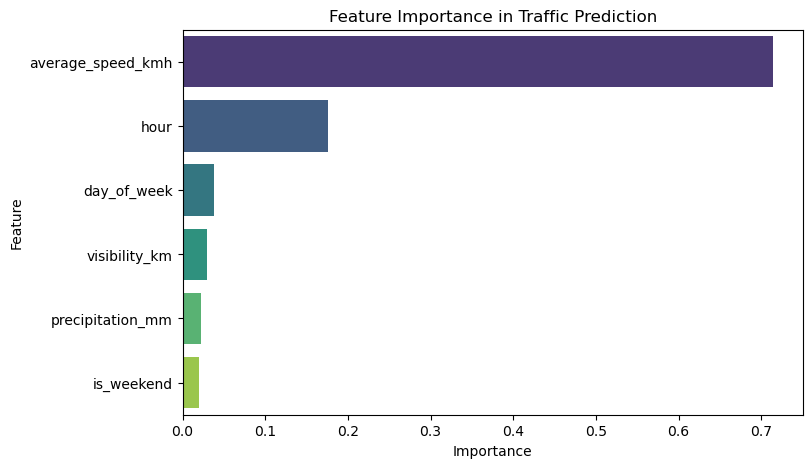

             Feature  Importance
3  average_speed_kmh    0.714429
0               hour    0.175417
1        day_of_week    0.038428
5      visibility_km    0.029957
4   precipitation_mm    0.022366
2         is_weekend    0.019404


In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
plt.title("Feature Importance in Traffic Prediction")
plt.show()

print(importance_df)


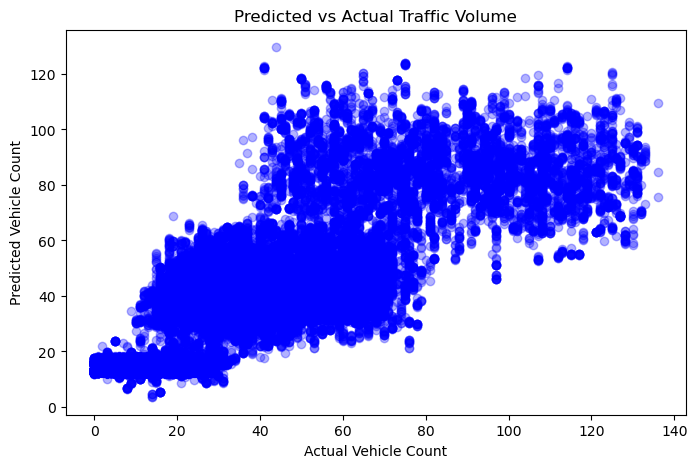

In [44]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.3, color="blue")
plt.xlabel("Actual Vehicle Count")
plt.ylabel("Predicted Vehicle Count")
plt.title("Predicted vs Actual Traffic Volume")
plt.show()



In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)


MAE: 11.322793179116191
RMSE: 15.417909885120523
R²: 0.6821872826462457


In [48]:
import pandas as pd

# Load a manageable slice of traffic data
traffic = pd.read_csv(
    "../data/traffic_sensor_data.csv",
    usecols=["sensor_id","timestamp","vehicle_count","average_speed_kmh"],
    nrows=50000
)

# Convert timestamp
traffic["timestamp"] = pd.to_datetime(traffic["timestamp"])


In [49]:
traffic["hour"] = traffic["timestamp"].dt.hour
traffic["day_of_week"] = traffic["timestamp"].dt.dayofweek
traffic["is_weekend"] = traffic["day_of_week"].isin([5,6]).astype(int)


In [50]:
weather_small = pd.read_csv(
    "../data/weather_conditions.csv",
    usecols=["timestamp","precipitation_mm","visibility_km"],
    nrows=50000
)

weather_small["timestamp"] = pd.to_datetime(weather_small["timestamp"])
traffic = traffic.merge(weather_small, on="timestamp", how="left")


In [51]:
traffic["vehicle_count_lag1"] = traffic["vehicle_count"].shift(1)
traffic["vehicle_count_lag2"] = traffic["vehicle_count"].shift(2)

# Drop rows with NaN from lagging
traffic = traffic.dropna()


In [52]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

X = traffic[["hour","day_of_week","is_weekend","average_speed_kmh",
             "precipitation_mm","visibility_km",
             "vehicle_count_lag1","vehicle_count_lag2"]]
y = traffic["vehicle_count"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

y_pred = gb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = gb_model.score(X_test, y_test)

print("Gradient Boosting MAE:", mae)
print("Gradient Boosting RMSE:", rmse)
print("Gradient Boosting R^2:", r2)


Gradient Boosting MAE: 2.2744478023561796
Gradient Boosting RMSE: 6.045538361732518
Gradient Boosting R^2: 0.9509972445271303


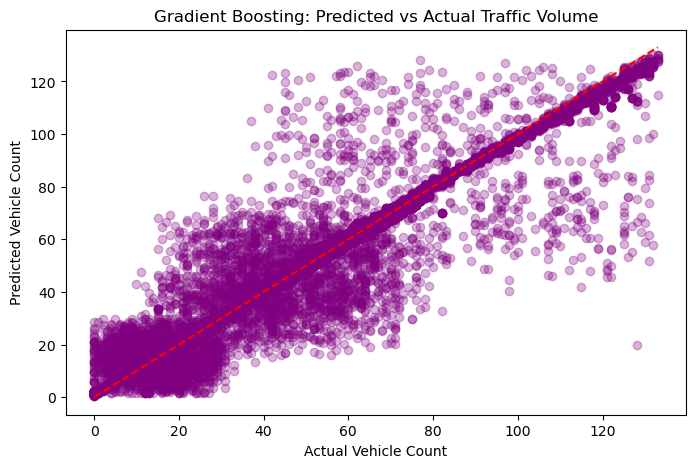

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.3, color="purple")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # perfect fit line
plt.xlabel("Actual Vehicle Count")
plt.ylabel("Predicted Vehicle Count")
plt.title("Gradient Boosting: Predicted vs Actual Traffic Volume")
plt.show()


In [56]:
results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting"],
    "R2": [0.682, r2],
    "MAE": [11.32, mae],
    "RMSE": [15.42, rmse]
})
print(results)


               Model        R2        MAE       RMSE
0      Random Forest  0.682000  11.320000  15.420000
1  Gradient Boosting  0.950997   2.274448   6.045538


In [58]:
import joblib

# Train your model (gb_model)
gb_model.fit(X_train, y_train)

# Save it
joblib.dump(gb_model, "../models/traffic_model.pkl")


['../models/traffic_model.pkl']

In [2]:
import os
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import numpy as np

# 1. Load and prepare data
traffic = pd.read_csv("../data/traffic_sensor_data.csv", nrows=50000)
weather = pd.read_csv("../data/weather_conditions.csv", usecols=["timestamp","precipitation_mm","visibility_km"], nrows=50000)

traffic["timestamp"] = pd.to_datetime(traffic["timestamp"])
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

# Merge traffic + weather
traffic = traffic.merge(weather, on="timestamp", how="left")

# Feature engineering
traffic["hour"] = traffic["timestamp"].dt.hour
traffic["day_of_week"] = traffic["timestamp"].dt.dayofweek
traffic["is_weekend"] = traffic["day_of_week"].isin([5,6]).astype(int)
traffic["vehicle_count_lag1"] = traffic["vehicle_count"].shift(1)
traffic["vehicle_count_lag2"] = traffic["vehicle_count"].shift(2)
traffic = traffic.dropna()

# Features and target
X = traffic[["hour","day_of_week","is_weekend","average_speed_kmh",
             "precipitation_mm","visibility_km",
             "vehicle_count_lag1","vehicle_count_lag2"]]
y = traffic["vehicle_count"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 2. Train model
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
gb_model.fit(X_train, y_train)

# 3. Evaluate
y_pred = gb_model.predict(X_test)
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

# 4. Save model
os.makedirs("../models", exist_ok=True)
joblib.dump(gb_model, "../models/traffic_model.pkl")
print("✅ Model saved to ../models/traffic_model.pkl")


MAE: 2.2744478023561796
RMSE: 6.045538361732518
R²: 0.9509972445271303
✅ Model saved to ../models/traffic_model.pkl


In [ ]:
import joblib

# Load the trained model
model = joblib.load(r"C:\Users\User\OneDrive\Desktop\AI-TRAFFIC-FLOW-OPTIMIZER\models\traffic_model.pkl")

# Now you can use it for predictions
sample = [[8, 0, 0, 40, 0.0, 10.0, 100, 95]]  # example input row
prediction = model.predict(sample)[0]
print("Predicted Vehicle Count:", prediction)


Predicted Vehicle Count: 97.8216217161705


c:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but GradientBoostingRegressor was fitted with feature names
  warnings.warn(


In [5]:
import pandas as pd

sample = pd.DataFrame({
    "hour": [8],
    "day_of_week": [0],
    "is_weekend": [0],
    "average_speed_kmh": [40],
    "precipitation_mm": [0.0],
    "visibility_km": [10.0],
    "vehicle_count_lag1": [100],
    "vehicle_count_lag2": [95]
})

prediction = gb_model.predict(sample)[0]
print("Predicted Vehicle Count:", prediction)


Predicted Vehicle Count: 97.8216217161705


In [6]:
import json, os

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
DATA_PATH = os.path.join(BASE_DIR, "data")

with open(os.path.join(DATA_PATH, "sensor_locations.json")) as f:
    sensor_data = json.load(f)

print(type(sensor_data))
print(sensor_data[:2] if isinstance(sensor_data, list) else list(sensor_data.items())[:2])


<class 'dict'>
[('dataset_info', {'name': 'Smart City Traffic Sensor Network - Jakarta', 'description': 'Metadata dan konfigurasi sensor lalu lintas di wilayah DKI Jakarta', 'total_sensors': 50, 'last_updated': '2024-03-31T23:55:00+07:00', 'coordinate_system': 'WGS84', 'coverage_area': 'DKI Jakarta dan sekitarnya'}), ('sensors', [{'sensor_id': 'SEN-001', 'location_name': 'Jl. Sudirman - Bundaran HI', 'coordinates': {'latitude': -6.337762, 'longitude': 106.853379}, 'sensor_type': 'Camera', 'installation_date': '2021-03-17', 'status': 'Active', 'coverage_direction': 'East', 'detection_range_m': 15, 'sampling_rate_seconds': 300, 'road_segment_id': 'RD-0126', 'district': 'Cakung', 'calibration_date': '2023-12-13', 'firmware_version': 'v2.2.3', 'communication_protocol': 'LoRaWAN', 'power_source': 'Hybrid', 'last_data_transmission': '2024-03-30 10:56:00', 'metadata': {'manufacturer': 'Siemens', 'model': 'X-Stream', 'height_m': 5.8, 'lane_coverage': 3, 'has_anpr': True, 'has_speed_enforcement

In [ ]:
locations = pd.DataFrame(sensor_data)
